# Install, authenticate and configure


Jing

In [ ]:
# ── FILL IN YOUR DETAILS ──────────────────────────────
project_id   = 'bdao-group-yelp'
bucket_name  = 'yelp-data-ima'
dataset_name = 'yelp_dataset'
# ──────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from datetime import datetime
from google.cloud import storage, bigquery
from google.colab import auth

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 15)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

# Authenticate to Google Cloud
auth.authenticate_user()

storage_client  = storage.Client(project=project_id)
bigquery_client = bigquery.Client(project=project_id)

def run_query(sql):
    """Run SQL on BigQuery and return a DataFrame."""
    return bigquery_client.query(sql).to_dataframe()

def load_to_bq(df, table_name):
    """Save a DataFrame to BigQuery."""
    df_bq = df.copy()
    for col in df_bq.select_dtypes(include=['datetime64']).columns:
        df_bq[col] = df_bq[col].astype(str)
    df_bq.to_gbq(f'{dataset_name}.{table_name}',
                 project_id=project_id, if_exists='replace', progress_bar=False)
    print(f'  Saved: {project_id}.{dataset_name}.{table_name} ({len(df_bq):,} rows)')

print(f'Connected: {project_id}')

Connected: bdao-group-yelp


# Diagnostic Visualisation（yelp_reviews）




Jing


##**Findings Summary**

The yelp_reviews dataset contains user-generated restaurant reviews with ratings, timestamps, and engagement metrics. From the diagnostic checks, I found that key fields have no missing values in the sample. Stars are within the expected 1–5 range. Useful, funny, and cool metrics are extremely right-skewed with a few high outliers. Text length varies widely, and some reviews are very short. Review counts differ significantly across years. Both business_id and user_id show natural concentration around a few active entities. These findings guide the cleaning work in the next phase.

##1. LIMIT

In [ ]:
# SAMPLE DATA FROM BIGQUERY
sample_sql = f"""
SELECT *
FROM `{project_id}.{dataset_name}.yelp_reviews`
LIMIT 50000
"""

df = bigquery_client.query(sample_sql).to_dataframe()
df.head()

,review_id,business_id,user_id,stars,useful,funny,cool,date,text
0,xzAwYp82eIXDl4vNzfGsLQ,85yx4a7CRJAQXkID6pWacA,zJ4cGJekT_Yoa4r4Q301yA,1.00,0,0,0,2016-08-19 21:45:44+00:00,Where do even start to sum it up...\nDo not st...
1,_NeNtGZ5kqfFiN5oDsjzBg,w6g1IXTqqvTtLMrUexkD6Q,mvPLf0wxQppsz5yEdQJDIA,1.00,0,0,0,2017-10-11 00:54:27+00:00,"This place is always packed, so I finally brok..."
2,JTW7iXi7yvTXeHdYOV6gYQ,7apWV3_bxbRcC2MemII9dQ,RndI8JX1Hx7HO0EO8ZwKPA,1.00,0,0,0,2018-06-30 00:34:20+00:00,Awful experience. Ordered happy hour appetizer...
3,sOQYeQTQSH60JEvriKMwJA,DfEYyoO1YPHEPy9h3BWGvQ,xGeVgi_cYECRErzx2jZ2LA,1.00,0,0,0,2017-02-04 00:22:00+00:00,Have not ate here in years and won't again 10 ...
4,zX6KL4KTZPpMejH14WmilQ,WzAxy5vdpQzahHIN4OMQnQ,U6hGEKCBr10LEB80ju_kOQ,1.00,0,0,0,2015-08-23 01:28:11+00:00,If one or two or even three little mistakes ha...


##2. Basic Check

In [ ]:
# Shape of sample
print("Shape:", df.shape)

# Column types
df.info()

# Basic stats
df.describe(include='all')

Shape: (50000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   review_id    50000 non-null  object             
 1   business_id  50000 non-null  object             
 2   user_id      50000 non-null  object             
 3   stars        50000 non-null  float64            
 4   useful       50000 non-null  Int64              
 5   funny        50000 non-null  Int64              
 6   cool         50000 non-null  Int64              
 7   date         50000 non-null  datetime64[us, UTC]
 8   text         50000 non-null  object             
dtypes: Int64(3), datetime64[us, UTC](1), float64(1), object(4)
memory usage: 3.6+ MB


,review_id,business_id,user_id,stars,useful,funny,cool,date,text
count,50000,50000,50000,50000.00,50000.00,50000.00,50000.00,50000,50000
unique,50000,21284,44315,NaN,<NA>,<NA>,<NA>,NaN,49999
top,phr_75I8etvRmFFBsvl1ZQ,IkY2ticzHEn4QFn8hQLSWg,1HM81n6n4iPIFU5d2Lokhw,NaN,<NA>,<NA>,<NA>,NaN,The location is perfect and the food is great....
freq,1,69,16,NaN,<NA>,<NA>,<NA>,NaN,2
mean,NaN,NaN,NaN,2.56,0.72,0.26,0.21,2016-10-06 20:02:21.403400+00:00,NaN
min,NaN,NaN,NaN,1.00,0.00,0.00,0.00,2005-03-09 03:24:06+00:00,NaN
25%,NaN,NaN,NaN,1.00,0.00,0.00,0.00,2014-09-04 20:45:40.750000+00:00,NaN
50%,NaN,NaN,NaN,3.00,0.00,0.00,0.00,2017-02-08 02:02:49.500000+00:00,NaN
75%,NaN,NaN,NaN,4.00,1.00,0.00,0.00,2019-03-08 03:12:07.250000+00:00,NaN
max,NaN,NaN,NaN,4.00,92.00,34.00,60.00,2022-01-19 18:11:29+00:00,NaN


##3. Missing Value

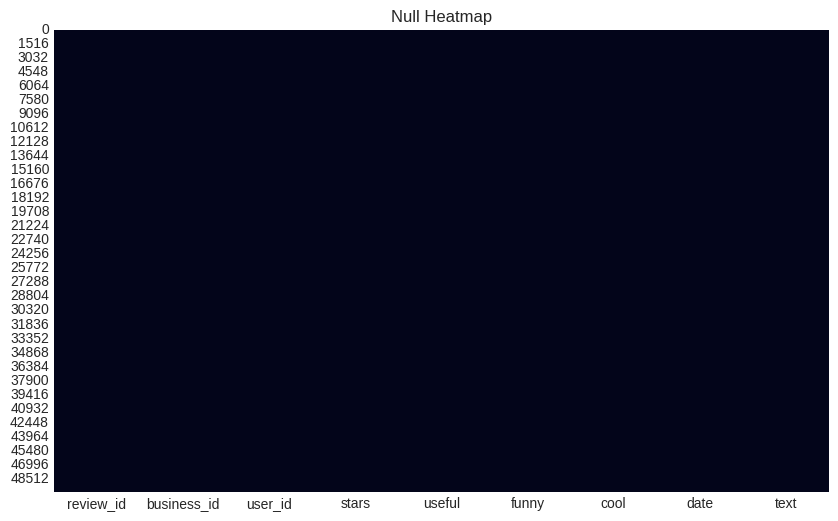

In [ ]:
import seaborn as sns

df.isnull().mean()

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Null Heatmap")
plt.show()

The null heatmap is fully dark, indicating no missing values in the 50,000-row sample.


##4. Duplicates

In [ ]:
print("Total duplicates:", df.duplicated().sum())

if 'review_id' in df.columns:
    print("Duplicate review_id:", df['review_id'].duplicated().sum())

Total duplicates: 0
Duplicate review_id: 0


##5. Generating Helper Features for Visualisation

In [ ]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['text_length'] = df['text'].astype(str).str.len()

##6. Diagnostic Charts

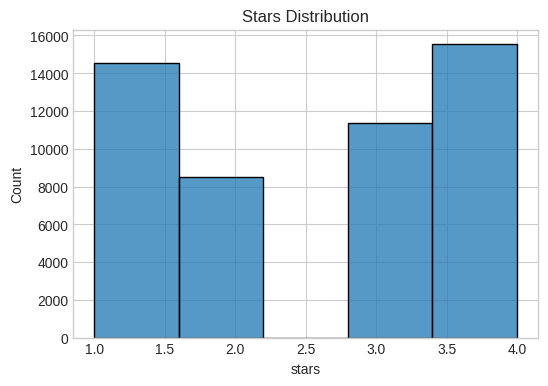

In [ ]:
#stars
plt.figure(figsize=(6,4))
sns.histplot(df['stars'], bins=5)
plt.title("Stars Distribution")
plt.show()

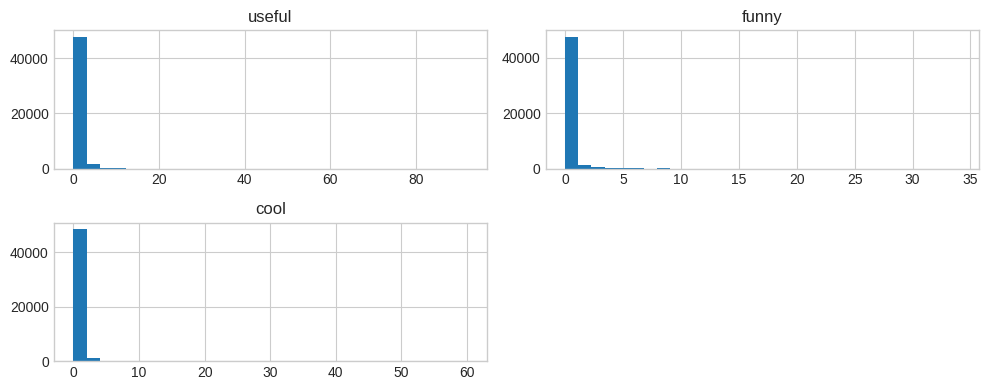

In [ ]:
#useful/funny/cool
df[['useful','funny','cool']].hist(bins=30, figsize=(10,4))
plt.tight_layout()
plt.show()

The useful, funny, and cool metrics show extreme right‑skewed distributions. Most reviews receive zero interaction, while a small number of reviews have very high values (e.g., >50). These outliers should be noted for downstream cleaning and analysis.

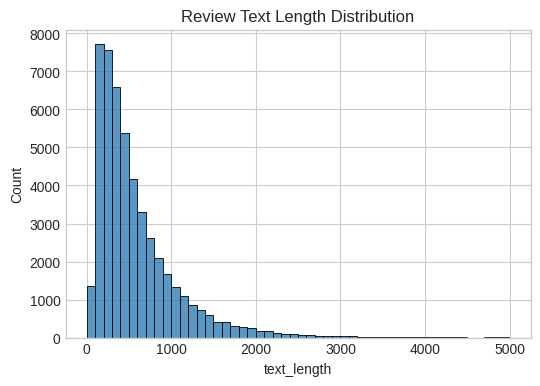

In [ ]:
#text length
plt.figure(figsize=(6,4))
sns.histplot(df['text_length'], bins=50)
plt.title("Review Text Length Distribution")
plt.show()

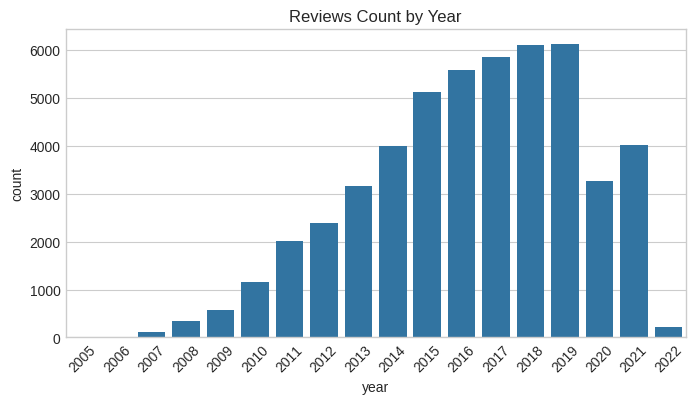

In [ ]:
#year
plt.figure(figsize=(8,4))
sns.countplot(x='year', data=df)
plt.xticks(rotation=45)
plt.title("Reviews Count by Year")
plt.show()

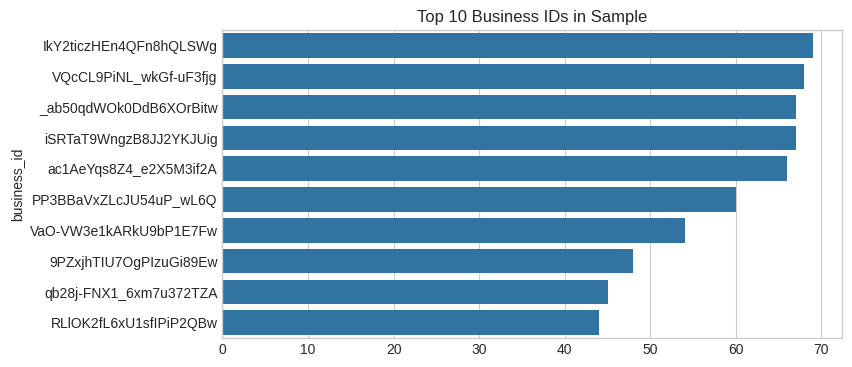

In [ ]:
#top business
biz_top = df['business_id'].value_counts().head(10)

plt.figure(figsize=(8,4))
sns.barplot(x=biz_top.values, y=biz_top.index)
plt.title("Top 10 Business IDs in Sample")
plt.show()

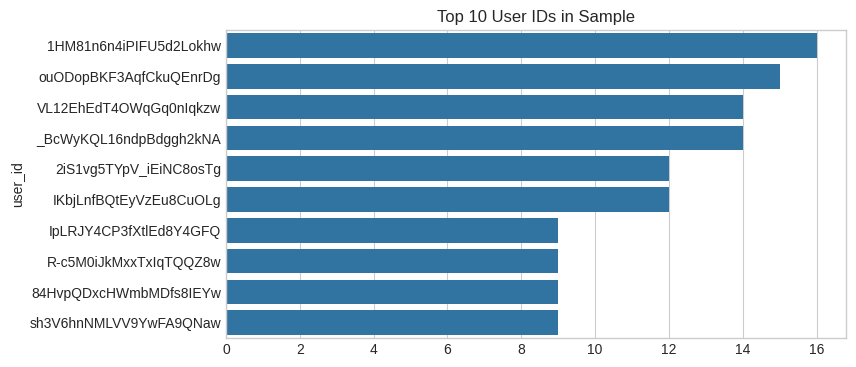

In [ ]:
#top users
user_top = df['user_id'].value_counts().head(10)

plt.figure(figsize=(8,4))
sns.barplot(x=user_top.values, y=user_top.index)
plt.title("Top 10 User IDs in Sample")
plt.show()

# New section

Bhavya - Define the business question + review Yelp Data Dictionary. Decide what we are trying to answer.

# New section

Huifang -

# Yihe — yelp_checkin

# Phase 1: Diagnostic visualisation


## 1. Overview and Findings Summary

The yelp_checkin table contains customer check-in records for Yelp businesses. The original table had two columns: business_id and date. The main data quality issue was that the date column stored multiple comma-separated timestamps in a single STRING field, meaning each row represented one business rather than one individual check-in. I cleaned the table by splitting the comma-separated date values into individual rows, trimming empty values, and converting each timestamp into a proper TIMESTAMP field. The cleaned table, yelp_checkin_clean, can now support analysis of yearly trends, weekday patterns, peak hours, and business-level visit activity.

## 2. BigQuery Connection Setup

In [ ]:
# Yihe Chen - setup

project_id = "bdao-group-yelp"
dataset_name = "yelp_dataset"

from google.cloud import bigquery
from google.colab import auth

auth.authenticate_user()

bigquery_client = bigquery.Client(project=project_id)

def run_query(sql):
    """Run SQL on BigQuery and return a DataFrame."""
    return bigquery_client.query(sql).to_dataframe()

print(f"Connected to: {project_id}.{dataset_name}")

Connected to: bdao-group-yelp.yelp_dataset


## 3. Cleaned Data Preview

In [ ]:
# Yihe Chen - yelp_checkin_clean sample data

sample_sql = f"""
SELECT *
FROM `{project_id}.{dataset_name}.yelp_checkin_clean`
LIMIT 50000
"""

df_checkin = run_query(sample_sql)
df_checkin.head()

,business_id,checkin_timestamp
0,-0FX23yAacC4bbLaGPvyxw,2021-10-06 18:39:44+00:00
1,-0G_6-KFGpCpxTUlVXCMYQ,2014-07-20 08:27:43+00:00
2,-0M0b-XhtFagyLmsBtOe8w,2017-08-12 00:00:07+00:00
3,-0TffRSXXIlBYVbb5AwfTg,2015-10-18 16:07:31+00:00
4,-0TffRSXXIlBYVbb5AwfTg,2016-01-29 02:01:10+00:00


## 4. Schema Check

Original table: `bdao-group-yelp.yelp_dataset.yelp_checkin`

| Column | Type | Description |
|---|---|---|
| business_id | STRING | Unique identifier for each Yelp business |
| date | STRING | Comma-separated check-in timestamps |

Cleaned table: `bdao-group-yelp.yelp_dataset.yelp_checkin_clean`

| Column | Type | Description |
|---|---|---|
| business_id | STRING | Unique identifier for each Yelp business |
| checkin_timestamp | TIMESTAMP | One timestamp per individual check-in |## 4. Schema Check

## 5. Shape, Data Types and Basic Statistics

In [ ]:
print("Shape:", df_checkin.shape)

print("\nColumn types:")
df_checkin.info()

print("\nBasic statistics:")
df_checkin.describe(include="all")

Shape: (50000, 2)

Column types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   business_id        50000 non-null  object             
 1   checkin_timestamp  50000 non-null  datetime64[us, UTC]
dtypes: datetime64[us, UTC](1), object(1)
memory usage: 781.4+ KB

Basic statistics:


,business_id,checkin_timestamp
count,50000,50000
unique,16411,NaN
top,FEXhWNCMkv22qG04E83Qjg,NaN
freq,343,NaN
mean,NaN,2015-11-18 03:31:19.600120+00:00
min,NaN,2010-01-16 19:20:44+00:00
25%,NaN,2013-09-19 21:05:58+00:00
50%,NaN,2015-09-26 04:32:54+00:00
75%,NaN,2017-12-07 20:14:43+00:00
max,NaN,2022-01-19 01:33:56+00:00


## 6. Missing Value Check

In [ ]:
# Missing value check

missing_pct = df_checkin.isnull().mean() * 100
missing_pct

,0
business_id,0.00
checkin_timestamp,0.00


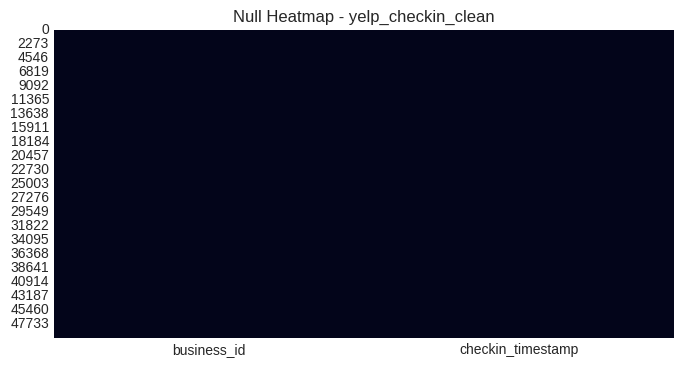

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.heatmap(df_checkin.isnull(), cbar=False)
plt.title("Null Heatmap - yelp_checkin_clean")
plt.show()

## 7. Duplicate Row Check

In [ ]:
# Duplicate rows check

print("Total duplicate rows:", df_checkin.duplicated().sum())

duplicate_checkins = df_checkin.duplicated(
    subset=["business_id", "checkin_timestamp"]
).sum()

print("Duplicate business_id + checkin_timestamp:", duplicate_checkins)

Total duplicate rows: 0
Duplicate business_id + checkin_timestamp: 0


## 8. Outlier and Extreme Value Check

In [ ]:
# timestamp range

time_range_sql = """
SELECT
  MIN(checkin_timestamp) AS earliest_checkin,
  MAX(checkin_timestamp) AS latest_checkin
FROM `bdao-group-yelp.yelp_dataset.yelp_checkin_clean`
"""

time_range_df = run_query(time_range_sql)
time_range_df

,earliest_checkin,latest_checkin
0,2009-12-30 02:53:27+00:00,2022-01-19 16:48:37+00:00


In [ ]:
# Check-ins per business distribution

business_checkin_sql = """
SELECT
  business_id,
  COUNT(*) AS total_checkins
FROM `bdao-group-yelp.yelp_dataset.yelp_checkin_clean`
GROUP BY business_id
"""

business_checkin_df = run_query(business_checkin_sql)
business_checkin_df.describe()

,total_checkins
count,51318.00
mean,165.94
std,467.06
min,1.00
25%,14.00
50%,46.00
75%,152.00
max,40109.00


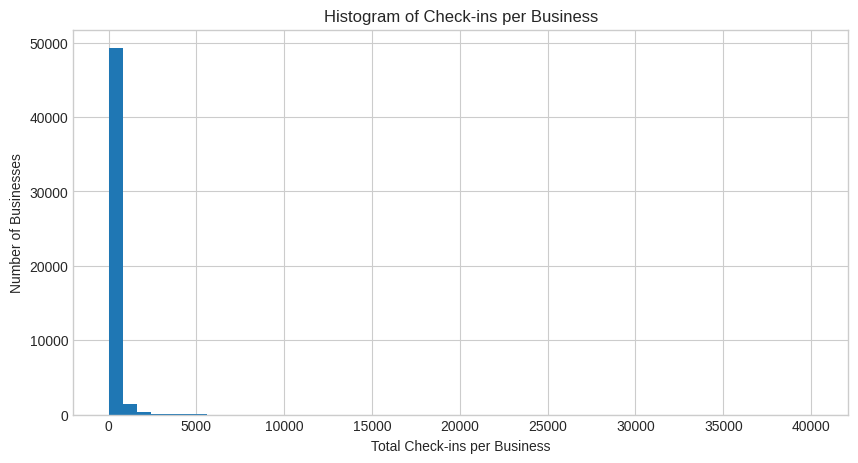

In [ ]:
# boxplot

plt.figure(figsize=(10, 5))
plt.hist(business_checkin_df["total_checkins"], bins=50)
plt.xlabel("Total Check-ins per Business")
plt.ylabel("Number of Businesses")
plt.title("Histogram of Check-ins per Business")
plt.show()

## 9. Top 10 businesses by check-ins

In [ ]:
top10_business_checkins = business_checkin_df.sort_values(
    "total_checkins", ascending=False
).head(10)

top10_business_checkins

,business_id,total_checkins
485,FEXhWNCMkv22qG04E83Qjg,40109
953,VQcCL9PiNL_wkGf-uF3fjg,28927
7074,ac1AeYqs8Z4_e2X5M3if2A,21542
13669,ytynqOUb3hjKeJfRj5Tshw,18615
7049,_ab50qdWOk0DdB6XOrBitw,15205
1490,onp9X_9RRAEzA-yqdiSOcA,13244
7457,oBNrLz4EDhiscSlbOl8uAw,10209
237,6Ty-KKWq6hLZYW8DWEHYvg,10135
20263,qb28j-FNX1_6xm7u372TZA,9574
12800,U4X-tzwvTzW8uWxs2KIPtg,9464


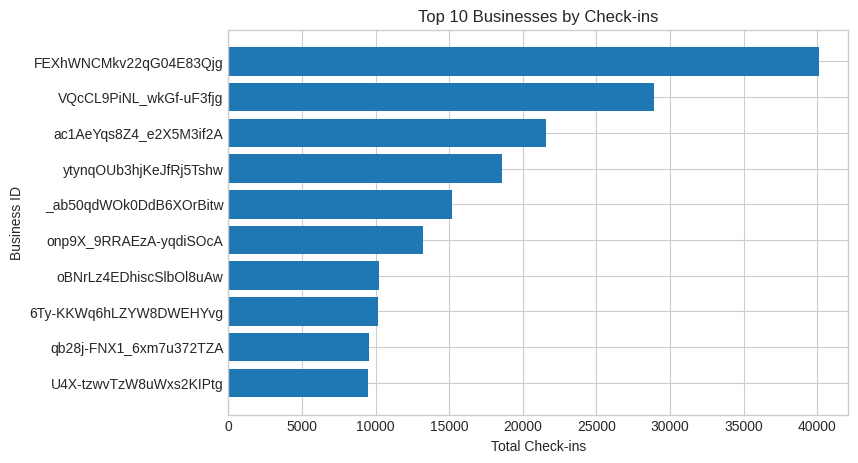

In [ ]:
plt.figure(figsize=(8, 5))
plt.barh(
    top10_business_checkins["business_id"],
    top10_business_checkins["total_checkins"]
)
plt.xlabel("Total Check-ins")
plt.ylabel("Business ID")
plt.title("Top 10 Businesses by Check-ins")
plt.gca().invert_yaxis()
plt.show()

The histogram shows that check-ins per business are highly right-skewed: most businesses have relatively low check-in counts, while a small number have extremely high activity. The top 10 business table identifies the specific businesses driving this long tail. These high values should not be removed automatically as outliers, because they may represent genuinely popular or high-traffic restaurants rather than data errors.

# Phase 2 & 3: Analytical visualisation

## 1. Cleaning Process

The table was cleaned in BigQuery using SQL. The comma-separated `date` field was split into individual timestamp strings using `SPLIT()`, expanded into separate rows using `UNNEST()`, trimmed to remove extra spaces, and converted into TIMESTAMP format using `SAFE.PARSE_TIMESTAMP()`.

Cleaned table created:

`bdao-group-yelp.yelp_dataset.yelp_checkin_clean`

In [ ]:
clean_sql = """
CREATE OR REPLACE TABLE `bdao-group-yelp.yelp_dataset.yelp_checkin_clean` AS
SELECT
  business_id,
  SAFE.PARSE_TIMESTAMP('%Y-%m-%d %H:%M:%S', TRIM(checkin_str)) AS checkin_timestamp
FROM `bdao-group-yelp.yelp_dataset.yelp_checkin`,
UNNEST(SPLIT(date, ',')) AS checkin_str
WHERE TRIM(checkin_str) != ''
"""

bigquery_client.query(clean_sql).result()
print("Cleaned table created: yelp_checkin_clean")

Cleaned table created: yelp_checkin_clean


## 2. Full Cleaned Table Validation

In [ ]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
client = bigquery.Client(project="bdao-group-yelp")

In [ ]:
validation_sql = """
SELECT
  COUNT(*) AS total_checkins,
  MIN(checkin_timestamp) AS earliest_checkin,
  MAX(checkin_timestamp) AS latest_checkin,
  COUNTIF(checkin_timestamp IS NULL) AS null_timestamps
FROM `bdao-group-yelp.yelp_dataset.yelp_checkin_clean`
"""

validation_df = run_query(validation_sql)
validation_df

,total_checkins,earliest_checkin,latest_checkin,null_timestamps
0,8515582,2009-12-30 02:53:27+00:00,2022-01-19 16:48:37+00:00,0


The cleaning and transformation process successfully converted the raw `yelp_checkin` table into an analysis-ready table. The original comma-separated timestamp strings were split into individual rows and parsed into a proper TIMESTAMP field. The cleaned table contains 8,515,582 check-in records with no null timestamps, confirming that the transformation was successful.

In [ ]:
query = """
SELECT COUNT(*) AS original_row_count
FROM `bdao-group-yelp.yelp_dataset.yelp_checkin`
"""
df_original_count = client.query(query).to_dataframe()
print(df_original_count)

   original_row_count
0               51318


The original table contained 51,318 rows, each representing one business with multiple comma-separated timestamps in the date column. After unnesting, the cleaned table contains 8,515,582 individual check-in records.

In [ ]:
query = """
SELECT COUNT(*) AS orphaned_checkins
FROM `bdao-group-yelp.yelp_dataset.yelp_checkin_clean` c
LEFT JOIN `bdao-group-yelp.yelp_dataset.yelp_restaurants` b
  ON c.business_id = b.business_id
WHERE b.business_id IS NULL
"""
df_orphaned = client.query(query).to_dataframe()
print(df_orphaned)

   orphaned_checkins
0                  0


All business_id values in the cleaned check-in table were successfully matched
to the yelp_restaurants table. No orphaned records were found. The cleaned
check-in table is ready to be joined with restaurant-level data using business_id.

## 3. Analytical Visualisation and Initial Analysis

### 3.1 Check-ins by Year

In [ ]:
# Check-ins by year

year_sql = """
SELECT
  EXTRACT(YEAR FROM checkin_timestamp) AS year,
  COUNT(*) AS total_checkins
FROM `bdao-group-yelp.yelp_dataset.yelp_checkin_clean`
GROUP BY year
ORDER BY year
"""

year_df = run_query(year_sql)
year_df

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(year_df["year"], year_df["total_checkins"], marker="o")
plt.xlabel("Year")
plt.ylabel("Total Check-ins")
plt.title("Yelp Check-ins by Year")
plt.xticks(year_df["year"], rotation=45)
plt.show()

Check-in volume rises steadily from 2009, peaks around 2015–2017, and declines in later years. This pattern is likely an artefact of the dataset rather than a true drop in restaurant activity — the Yelp dataset is a static snapshot export, so more recent years are naturally underrepresented. 2009 and 2022 are also partial years and should not be directly compared with full-year figures.

### 3.2 Check-ins by Month

In [ ]:
# Check-ins by month

month_sql = """
SELECT
  EXTRACT(MONTH FROM checkin_timestamp) AS month,
  COUNT(*) AS total_checkins
FROM `bdao-group-yelp.yelp_dataset.yelp_checkin_clean`
GROUP BY month
ORDER BY month
"""

month_df = run_query(month_sql)
month_df

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(month_df["month"], month_df["total_checkins"])
plt.xlabel("Month")
plt.ylabel("Total Check-ins")
plt.title("Yelp Check-ins by Month")
plt.xticks(range(1, 13))
plt.show()

The monthly distribution provides an initial view of seasonality in customer check-in activity. Some months show slightly higher check-in volumes than others, suggesting that visit activity may vary across the year. However, this pattern should be interpreted carefully because it aggregates all years and all business types together.

### 3.3 Check-ins by Hour of Day

In [ ]:
# Check-ins by hour of day

hour_sql = """
SELECT
  EXTRACT(HOUR FROM checkin_timestamp) AS checkin_hour,
  COUNT(*) AS total_checkins
FROM `bdao-group-yelp.yelp_dataset.yelp_checkin_clean`
GROUP BY checkin_hour
ORDER BY checkin_hour
"""

hour_df = run_query(hour_sql)
hour_df

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(hour_df["checkin_hour"], hour_df["total_checkins"])
plt.xlabel("Hour of Day")
plt.ylabel("Total Check-ins")
plt.title("Yelp Check-ins by Hour of Day")
plt.xticks(range(0, 24))
plt.show()

This suggests that restaurants may experience clear peak and off-peak periods, which could support operational decisions such as staffing, opening hours, and promotion timing. However, all timestamps are stored and analysed in UTC. Since Yelp businesses are located across multiple US time zones, the actual local hour of each check-in may differ from the UTC hour shown here. Hour-of-day patterns should therefore be interpreted as approximate trends rather than precise local-time figures.

### 3.4 Check-ins by Day of Week

In [ ]:
# Check-ins by day of week

weekday_sql = """
SELECT
  FORMAT_TIMESTAMP('%A', checkin_timestamp) AS day_of_week,
  COUNT(*) AS total_checkins
FROM `bdao-group-yelp.yelp_dataset.yelp_checkin_clean`
GROUP BY day_of_week
ORDER BY total_checkins DESC
"""

weekday_df = run_query(weekday_sql)
weekday_df

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(weekday_df["day_of_week"], weekday_df["total_checkins"])
plt.xlabel("Day of Week")
plt.ylabel("Total Check-ins")
plt.title("Yelp Check-ins by Day of Week")
plt.xticks(rotation=45)
plt.show()

This suggests that customer visits are more concentrated around leisure-focused days. For restaurant owners, this pattern can support weekend staffing, stock planning, and targeted promotions.

### 3.5 Initial Findings

The cleaned `yelp_checkin` table contains 8,515,582 individual check-in records from 2009-12-30 to 2022-01-19. The original raw table was not analysis-ready because each business stored all check-in timestamps in one comma-separated STRING field. After splitting and parsing these timestamps, the cleaned table now supports time-based analysis.

The validation results show 0 null timestamps, which suggests that the timestamp parsing process was successful. The distribution of check-ins per business is highly right-skewed: the median business has 46 check-ins, while the highest business has 40,109 check-ins. These high values should be interpreted as potentially high-engagement businesses rather than removed automatically.

The time-based visualisations by year, month, weekday, and hour provide the basis for understanding customer visit patterns. These results can support later business recommendations around peak visit periods, seasonality, staffing, promotion timing, and restaurant engagement.

### Check-in Part Summary

The yelp_checkin table records customer check-in activity across 51,318 businesses. The original table stored multiple timestamps in a single comma-separated date column. After unnesting, the cleaned table yelp_checkin_clean contains 8,515,582 individual check-in records with zero null timestamps were found in the full validation, and no duplicate records were found in the checked sample. Check-in activity peaks on weekends and during evening hours. Volume peaks around 2015–2017, with later years underrepresented due to the dataset being a static snapshot. The distribution is highly right-skewed, with most businesses having low check-in counts. All business_id values match yelp_restaurants, confirming the table is ready for joining. Key derivable features include total check-ins, weekend ratios, and hourly patterns.

Lady -

# New section

weiyi

# Qinxin-users



#1. Overview and finding summary
The yelp_users table contains metadata about Yelp users, including their social connections (friends) and various behavior attributes. This section focuses on data quality checks on the entire table, including missing value, duplicates and spot check to ensure the data is reliable and suitable for further analysis. Following data quality checks, the users were analyzed from multiple perspectives: activity level (review_count), rating behaviors (average_stars), social influence (combined measure of fans and review_count, as well as fans-per-review_count efficiency), elite status, and users growth trends overtime.

In [ ]:
# Stage 1: Install, Authenticate and Setup
# 1. Install required packages
!pip install google-cloud-storage google-cloud-bigquery pandas-gbq --quiet
print('Packages installed.')

# 2. Authenticate Google account
from google.colab import auth
auth.authenticate_user()
print('Authenticated.')

# 3. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from google.cloud import storage
from google.cloud import bigquery

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

# 4. Set group project details
project_id   = 'bdao-group-yelp'
bucket_name  = 'yelp-data-ima'
dataset_name = 'yelp_dataset'

# 5. Set Qinxin's assigned table
users_table_name = 'yelp_users'
users_table_id = f'{project_id}.{dataset_name}.{users_table_name}'
users_sample_size = 100000

# 6. Connect to Google Cloud
storage_client = storage.Client(project=project_id)
bigquery_client = bigquery.Client(project=project_id)

# 7. Helper function for BigQuery
def run_query(sql):
    """
    Run a SQL query on BigQuery and return the result as a pandas DataFrame.
    """
    return bigquery_client.query(sql).to_dataframe()

# 8. Check connection
print('Setup complete.')
print(f'Connected to GCP project: {project_id}')
print(f'Storage bucket: gs://{bucket_name}')
print(f'BigQuery dataset: {project_id}.{dataset_name}')
print(f'Xuanying working table: {users_table_id}')
print(f'Sample size: {users_sample_size:,} rows')

Packages installed.
Authenticated.
Setup complete.
Connected to GCP project: bdao-group-yelp
Storage bucket: gs://yelp-data-ima
BigQuery dataset: bdao-group-yelp.yelp_dataset
Xuanying working table: bdao-group-yelp.yelp_dataset.yelp_users
Sample size: 100,000 rows


In [ ]:
# Stage 2: Data Checking and Validation
print('=== Schema & entire Rows in BigQuery ===')


# Entire yeld_users row count from BigQuery
print('\n--- Full table row count ---')

row_count_df = run_query(f"""
    SELECT COUNT(*) AS total_rows
    FROM `{users_table_id}`
""")

display(row_count_df)

# 3. yelf_users Schema in BigQuery
print('\n--- Schema in Bigquery ---')

schema_df = run_query(f"""
    SELECT
        column_name,
        data_type,
        is_nullable
    FROM `{project_id}.{dataset_name}.INFORMATION_SCHEMA.COLUMNS`
    WHERE table_name = '{users_table_name}'
    ORDER BY ordinal_position
""")

display(schema_df)

=== Schema & entire Rows in BigQuery ===

--- Full table row count ---


,total_rows
0,1446025



--- Schema in Bigquery ---


,column_name,data_type,is_nullable
0,user_id,STRING,YES
1,name,STRING,YES
2,review_count,INT64,YES
3,average_stars,FLOAT64,YES
4,useful,INT64,YES
5,funny,INT64,YES
6,cool,INT64,YES
7,fans,INT64,YES
8,elite,FLOAT64,YES
9,yelping_since,TIMESTAMP,YES


In [ ]:
# Check invalid value for numerical fields in yeld_users in BigQuery
print('\n--- Negative value check from BigQuery ---')

negative_value_check = run_query(f"""
    SELECT
        COUNT(*) AS total_rows,

        COUNTIF(review_count < 0) AS negative_review_count,
        COUNTIF(useful < 0) AS negative_useful,
        COUNTIF(funny < 0) AS negative_funny,
        COUNTIF(cool < 0) AS negative_cool,
        COUNTIF(fans < 0) AS negative_fans,
        COUNTIF(average_stars < 0) AS negative_average_stars

    FROM `{users_table_id}`
""")

display(negative_value_check)



--- Negative value check from BigQuery ---


,total_rows,negative_review_count,negative_useful,negative_funny,negative_cool,negative_fans,negative_average_stars
0,1446025,0,0,0,0,0,0


Normally the fields 'review_count', 'useful','funny','cool','fans' and 'average_stars'should not contain nagative values,as these fields reprensent counts and rating scores. The nagative value check was conducted to identify any invalid or inconsistent records in the table. The result shows that no negative values were found,indicating that the data is logically consistent and meets the expected data quality requirements.

In [ ]:
# Spot Check to endire yeld_users in BigQuery: 0<average_stars<5; users_id not NULL; user_id is not ' '; Length of user_id should be 22
print('\n=== Spot Checks: Yelp Users Data Quality ===')

spot_check = run_query(f"""
    SELECT
        COUNT(*) AS total_rows,

        -- Invalid average_stars checks
        COUNTIF(average_stars < 0) AS negative_average_stars,
        COUNTIF(average_stars > 5) AS invalid_high_average_stars,

        -- user_id quality checks
        COUNTIF(user_id IS NULL) AS null_user_id,
        COUNTIF(TRIM(user_id) = '') AS empty_user_id,
        COUNTIF(LENGTH(user_id) != 22) AS invalid_user_id_length

    FROM `{users_table_id}`
""")

display(spot_check)


=== Spot Checks: Yelp Users Data Quality ===


,total_rows,negative_average_stars,invalid_high_average_stars,null_user_id,empty_user_id,invalid_user_id_length
0,1446025,0,0,0,0,0


A spot check was conducted on the entire yeld_users table to identify potentical data quality issues. The validation foucsed on that average_starts value fall within the valid Yelp rating range of 0 to 5. In addtion,since user_id serves as the primary key of the table, it was checked to ensure that it does not caontain NULL or empty value, and the each user_id has the expected length of 22 characters. The result shows that there is no data quality issue.

In [ ]:
# Duplicate checking (Exact duplicatate & Logical duplicate) entire table in BigQuery

print('\n--- Full table Exact duplicate check from BigQuery ---')

full_exact_duplicate_check = run_query(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT TO_JSON_STRING(t)) AS distinct_exact_rows,
        COUNT(*) - COUNT(DISTINCT TO_JSON_STRING(t)) AS exact_duplicate_rows
    FROM `{users_table_id}` AS t
""")

display(full_exact_duplicate_check)



print('\n--- Full table logical duplicate check from BigQuery ---')

full_logical_duplicate_check = run_query(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT CONCAT(
            CAST(user_id AS STRING)

        )) AS distinct_logical_rows,
        COUNT(*) - COUNT(DISTINCT CONCAT(
            CAST(user_id AS STRING)

        )) AS logical_duplicate_rows
    FROM `{users_table_id}`
""")

display(full_logical_duplicate_check)




--- Full table Exact duplicate check from BigQuery ---


,total_rows,distinct_exact_rows,exact_duplicate_rows
0,1446025,1446025,0



--- Full table logical duplicate check from BigQuery ---


,total_rows,distinct_logical_rows,logical_duplicate_rows
0,1446025,1446025,0


Two types of dupliate checks were performed on the entire yeld_users table in BigQuery. The first check identified exact duplicates, where all fields in a records are identical. The second check identified logical duplicates, where records share the same user_id. The results show that no exact duplicates or logical duplicates were found, indicating that the table does not contain duplicate records.

=== Missing value checking to entire table yeld_usersin BigQuery) ===


,total_rows,user_id_missing_count,name_missing_count,review_count_missing_count,average_stars_missing_count,useful_missing_count,funny_missing_count,cool_missing_count,fans_missing_count,elite_missing_count,yelping_since_missing_count
0,1446025,0,0,0,0,0,0,0,0,1361865,0



=== Missing Value Summary (Full Table) ===


,missing_count,missing_percentage
elite_missing_count,1361865,94.18
user_id_missing_count,0,0.00
name_missing_count,0,0.00
review_count_missing_count,0,0.00
useful_missing_count,0,0.00
average_stars_missing_count,0,0.00
funny_missing_count,0,0.00
cool_missing_count,0,0.00
fans_missing_count,0,0.00
yelping_since_missing_count,0,0.00



=== Diagnostic Chart: Missing Value Percentage ===


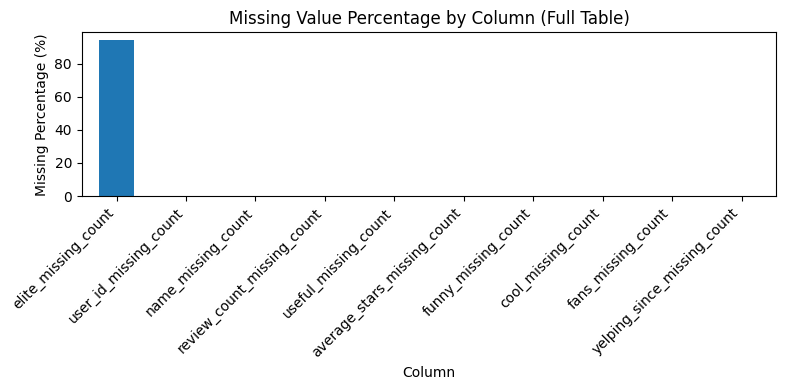

,user_id,name,review_count,average_stars,useful,funny,cool,fans,elite,yelping_since
0,VPHDEyaX2MUMSRj1em3mxg,Senna,293,2.87,707,483,400,39,20072008200920100864.00,2007-06-07 06:28:52+00:00
1,bpf_l7bnDs96VsEgS97f8A,Robert,680,2.90,981,289,228,34,20172018201920200704.00,2013-09-07 16:45:06+00:00
2,T2SwMzewL5wLnFI7aUcv0g,Peter,107,2.92,452,323,216,46,20162017201920200704.00,2013-05-07 15:04:41+00:00
3,gQcK5VDJsWo3RJ4VDn1E3A,Anthony,271,2.93,703,525,366,83,20152016201720180736.00,2012-09-20 00:15:48+00:00
4,YdiZnp5_rc00SWUZybeXgg,Maria,299,2.93,1132,269,490,51,20202021.00,2010-05-04 03:48:27+00:00


In [ ]:
# Missing value checkign to entire table yeld_users in BigQuery
print('=== Missing value checking to entire table yeld_usersin BigQuery) ===')

# 1. Get column names first
columns_df = run_query(f"""
    SELECT column_name
    FROM `{project_id}.{dataset_name}.INFORMATION_SCHEMA.COLUMNS`
    WHERE table_name = 'yelp_users'
""")

columns = columns_df['column_name'].tolist()

# 2. Build dynamic SQL to count NULLs for each column
null_checks = []

for col in columns:
    null_checks.append(f"""
        COUNTIF({col} IS NULL) AS {col}_missing_count
    """)

missing_sql = f"""
SELECT
    COUNT(*) AS total_rows,
    {", ".join(null_checks)}
FROM `{project_id}.{dataset_name}.yelp_users`
"""

# 3. Run query
missing_result = run_query(missing_sql)

display(missing_result)

# 4. Calculate missing percentages
total_rows = missing_result['total_rows'][0]

missing_counts = missing_result.drop(columns=['total_rows']).iloc[0]

missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percentage': (missing_counts / total_rows * 100).round(2)
}).sort_values('missing_percentage', ascending=False)

print('\n=== Missing Value Summary (Full Table) ===')
display(missing_summary)

# 5. Diagnostic Chart
print('\n=== Diagnostic Chart: Missing Value Percentage ===')

if missing_summary['missing_percentage'].max() == 0:
    print('No missing values were found in the full yelp_users table.')
else:
    plt.figure(figsize=(8, 4))
    missing_summary['missing_percentage'].plot(kind='bar')
    plt.title('Missing Value Percentage by Column (Full Table)')
    plt.ylabel('Missing Percentage (%)')
    plt.xlabel('Column')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
# List the rows in yeld_users where the file 'elite' is not null
elite_not_null_sql = f"""
SELECT *
FROM `{project_id}.{dataset_name}.yelp_users`
WHERE elite IS NOT NULL
"""

df_elite = bigquery_client.query(elite_not_null_sql).to_dataframe()

df_elite.head()


Missing value check were performed on the entire table yeld_users in BigQuery. The result indicates that there are no missing value aross the fields in the table.However, 94.18% of total users are not elite users (null value in elite field), this means only a small proportion of users achieve elite stauts in Yelp.


=== Top 10 users with highest review_count ===


,user_id,name,review_count,useful,funny,cool,fans,average_stars
0,Hi10sGSZNxQH3NLyWSZ1oA,Fox,17473,206296,185823,195814,3493,3.77
1,8k3aO-mPeyhbR5HUucA5aA,Victor,16978,152979,84992,125516,1462,3.35
2,hWDybu_KvYLSdEFzGrniTw,Bruce,16567,173089,98459,144849,867,3.67
3,RtGqdDBvvBCjcu5dUqwfzA,Shila,12868,11109,3747,3292,300,3.87
4,P5bUL3Engv-2z6kKohB6qQ,Kim,9941,27549,10772,21375,825,3.81
5,nmdkHL2JKFx55T3nq5VziA,Nijole,8363,57242,28960,46435,921,3.75
6,bQCHF5rn5lMI9c5kEwCaNA,Vincent,8354,42959,21176,36600,362,3.87
7,8RcEwGrFIgkt9WQ35E6SnQ,George,7738,8110,3868,3165,288,3.49
8,Xwnf20FKuikiHcSpcEbpKQ,Kenneth,6766,8348,3624,5062,285,3.32
9,CxDOIDnH8gp9KXzpBHJYXw,Jennifer,6679,23254,9326,14773,828,3.34


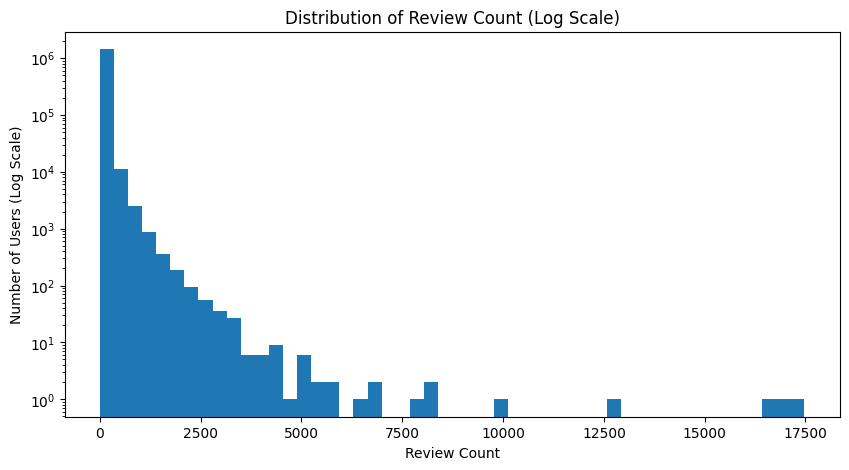

In [ ]:
# Stage 3: Data Analysis
# List the top 10 users with highest revew_counts in BigQuery （user activity)
print('\n=== Top 10 users with highest review_count ===')

top_users = run_query(f"""
    SELECT
        user_id,
        name,
        review_count,
        useful,
        funny,
        cool,
        fans,
        average_stars
    FROM `{project_id}.{dataset_name}.yelp_users`
    ORDER BY review_count DESC
    LIMIT 10
""")

display(top_users)


# Review activity distribution
review_dist = run_query(f"""
SELECT
    review_count,
    COUNT(*) AS user_count
FROM `{project_id}.{dataset_name}.yelp_users`
GROUP BY review_count
ORDER BY review_count
""")



# Histogram with Log Scale

import matplotlib.pyplot as plt

# 查询原始数据
review_data = run_query(f"""
    SELECT review_count
    FROM `{project_id}.{dataset_name}.yelp_users`
""")

plt.figure(figsize=(10,5))

# 直方图（分箱）
plt.hist(
    review_data['review_count'],
    bins=50
)

# ⭐ 关键：设置 y 轴为对数坐标
plt.yscale('log')

plt.title("Distribution of Review Count (Log Scale)")
plt.xlabel("Review Count")
plt.ylabel("Number of Users (Log Scale)")

plt.show()

The top 10 users with highest review_count listed.
For all users, the review count distribution is highly right-skewed with a long-tail pattern. Most users have very low activity levels, while a small number of users contribute disproportionately large numbers of reviews.

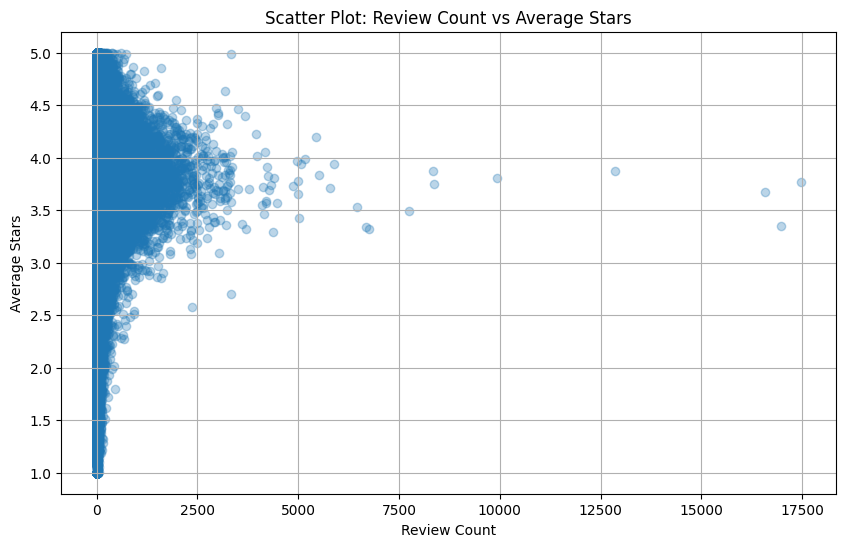

In [ ]:
#High rating vs low activity correlation （check if the high average_starts is more average review_count)

# Scatter plot: Review Count vs Average Stars (User-level)

import matplotlib.pyplot as plt

# 直接使用用户原始数据
users = run_query(f"""
SELECT
    review_count,
    average_stars
FROM `{project_id}.{dataset_name}.yelp_users`
""")

plt.figure(figsize=(10,6))

plt.scatter(
    users['review_count'],
    users['average_stars'],
    alpha=0.3   # ⭐ 透明度，避免点重叠
)

plt.title("Scatter Plot: Review Count vs Average Stars")
plt.xlabel("Review Count")
plt.ylabel("Average Stars")

plt.grid(True)
plt.show()

The scatter plot shows no strong linear relationship between review count and average star rating. User activity level does not appear to significantly influence rating behavior. The distribution is highly concentrated at low review counts, indicating most of users are not active.

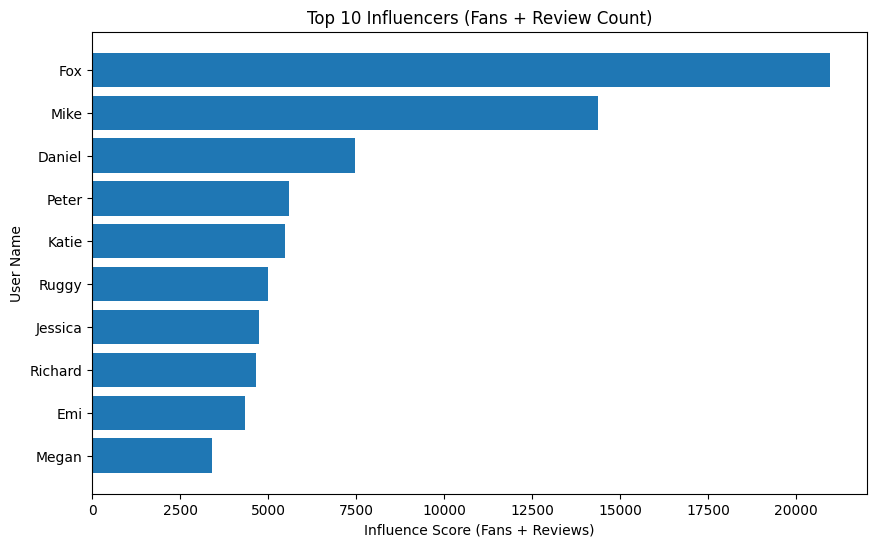

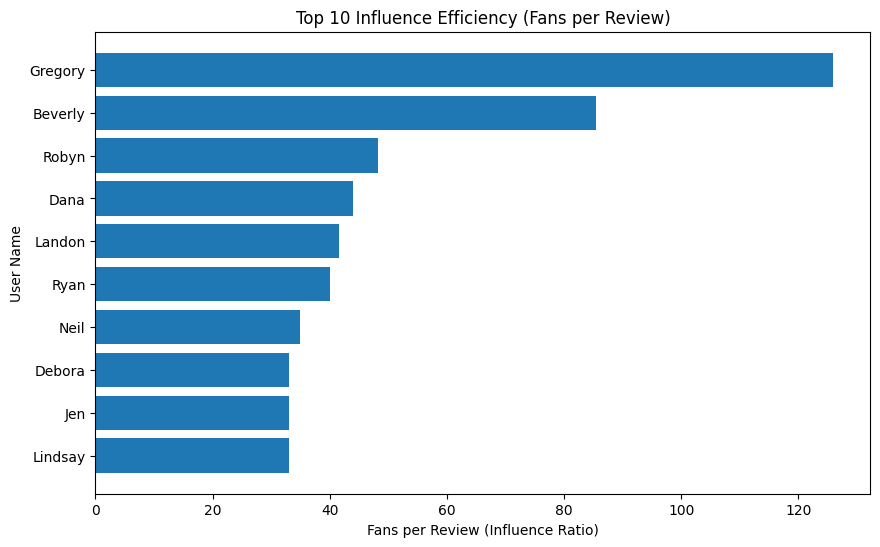

In [ ]:
# Top influencers (fans + review_count combined)
import matplotlib.pyplot as plt

top_influencers = run_query(f"""
SELECT
  user_id,
  name,
  fans,
  review_count
FROM `{project_id}.{dataset_name}.yelp_users`
ORDER BY fans DESC, review_count DESC
LIMIT 10
""")

# Create combined influence score (optional but recommended)
top_influencers['influence_score'] = (
    top_influencers['fans'] + top_influencers['review_count']
)

# Sort for better visualization
top_influencers = top_influencers.sort_values('influence_score')

plt.figure(figsize=(10,6))

plt.barh(
    top_influencers['name'],
    top_influencers['influence_score']
)

plt.title("Top 10 Influencers (Fans + Review Count)")
plt.xlabel("Influence Score (Fans + Reviews)")
plt.ylabel("User Name")

plt.show()

# Fans efficiency (Fans per review_count)
import matplotlib.pyplot as plt

influence_efficiency = run_query(f"""
SELECT
  user_id,
  name,
  fans,
  review_count,
  fans / NULLIF(review_count, 0) AS influence_ratio
FROM `{project_id}.{dataset_name}.yelp_users`
WHERE review_count > 0
ORDER BY influence_ratio DESC
LIMIT 10
""")

# sort for better horizontal bar display
influence_efficiency = influence_efficiency.sort_values('influence_ratio')

plt.figure(figsize=(10,6))

plt.barh(
    influence_efficiency['name'],
    influence_efficiency['influence_ratio']
)

plt.title("Top 10 Influence Efficiency (Fans per Review)")
plt.xlabel("Fans per Review (Influence Ratio)")
plt.ylabel("User Name")

plt.show()

The two visualisations reveal different dimensions of user influence on Yelp. The first chart measures overall influence using a combined score of fans and review counts, highlighting highly active “power users” such as Fox and Mike. In contrast, the second chart focuses on influence efficiency, defined as the number of fans gained per review. Users such as Gregory and Beverly achieve significantly higher influence efficiency, suggesting that their reviews generate stronger engagement despite potentially lower activity levels. Together, these findings indicate that user influence on Yelp is driven not only by review volume but also by the quality and impact of contributions.

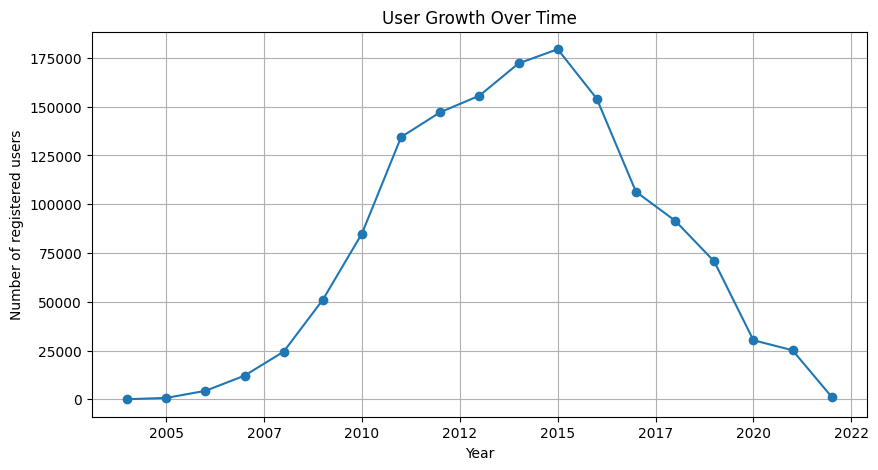

In [ ]:
# User growth over time


import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

user_growth = run_query(f"""
SELECT
  EXTRACT(YEAR FROM DATE(yelping_since)) AS year,
  COUNT(*) AS users
FROM `{project_id}.{dataset_name}.yelp_users`
GROUP BY year
ORDER BY year
""")

# 确保数据是 int
user_growth['year'] = user_growth['year'].astype(int)

plt.figure(figsize=(10,5))

plt.plot(
    user_growth['year'],
    user_growth['users'],
    marker='o'
)

plt.title("User Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of registered users")

# ✅ 强制 x 轴显示整数
plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

plt.grid(True)
plt.show()

The “User Growth Over Time” chart illustrates annual new user registrations from 2004 to 2022. New sign-ups rose rapidly from near-zero levels to a peak of ~180,000 in 2015, followed by a sustained, steep decline. By 2022, annual new registrations had fallen to nearly zero, indicating a dramatic collapse in user acquisition momentum over the period.

In [ ]:
# List and Rank the elite users by their elite years
print('\n=== Users ranked by number of valid elite years ===')

elite_users = run_query(f"""
WITH parsed AS (
    SELECT
        user_id,
        name,
        CAST(elite AS STRING) AS elite_str
    FROM `{project_id}.{dataset_name}.yelp_users`
    WHERE elite IS NOT NULL
),

extracted AS (
    SELECT
        user_id,
        name,
        elite_str,

        -- ✅ 用正则从脏字符串中提取所有 2000-2026 年份
        REGEXP_EXTRACT_ALL(elite_str, r'(20[0-2][0-9])') AS elite_years
    FROM parsed
),

flattened AS (
    SELECT
        user_id,
        name,
        CAST(year AS INT64) AS elite_year
    FROM extracted,
    UNNEST(elite_years) AS year
),

valid_years AS (
    SELECT
        user_id,
        name,
        elite_year
    FROM flattened
    WHERE elite_year BETWEEN 2000 AND 2026
)

SELECT
    user_id,
    name,

    -- 每个用户 elite 年份数量
    COUNT(elite_year) AS elite_year_count

FROM valid_years
GROUP BY user_id, name
ORDER BY elite_year_count DESC
""")

display(elite_users)


=== Users ranked by number of valid elite years ===


,user_id,name,elite_year_count
0,yXIFCpTAJkKzyoWXm4opqg,Steve,4
1,iluhUML2Uf8ubwJG4riUtQ,David,4
2,X9GYRJUva58wvPdgqoJk6Q,Christine,4
3,5mJMKsqVLf8JcV4Mxy8wZQ,Heidi,4
4,tNvg-kX53h2toFoBIhqnVg,matthew,4
...,...,...,...
84155,wuezi2Ui3Mpllv9jaC0UVQ,Saeed,1
84156,HeJiXwmXqfvXAOgkxKfh6A,Shayne,1
84157,VH57IWo0GtzXJuHWpHLy5Q,Christopher,1
84158,-TpW23o5mDdiG5rF8SZkOQ,Carey,1


# Xuanying-Tips

## 1. Overview and finding summary

The `yelp_tips` table contains short customer feedback linked to users and businesses. This section uses a 100,000-row random sample for diagnostic validation and selected BigQuery checks for full-table confirmation. The key fields are `user_id`, `business_id`, `text`, `date`, and `compliment_count`. Overall, the data quality is relatively good: no actual missing values were found in the sample, only one placeholder-like text value appeared, and duplicates are rare. The main issues are sparse `compliment_count`, repeated records, and variation in tip text length. Later cleaning should remove or flag duplicates, check placeholder text, parse dates consistently, and create useful features such as `text_length`, year, hour, and day of week.

## 2. Setup

In [ ]:

# 1. Install required packages
!pip install google-cloud-storage google-cloud-bigquery pandas-gbq --quiet
print('Packages installed.')

# 2. Authenticate Google account
from google.colab import auth
auth.authenticate_user()
print('Authenticated.')

# 3. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from google.cloud import storage
from google.cloud import bigquery

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

# 4. Set group project details
project_id   = 'bdao-group-yelp'
bucket_name  = 'yelp-data-ima'
dataset_name = 'yelp_dataset'

# 5. Set Xuanying's assigned table
tips_table_name = 'yelp_tips'
tips_table_id = f'{project_id}.{dataset_name}.{tips_table_name}'
tips_sample_size = 100000

# 6. Connect to Google Cloud
storage_client = storage.Client(project=project_id)
bigquery_client = bigquery.Client(project=project_id)

# 7. Helper function for BigQuery
def run_query(sql):
    """
    Run a SQL query on BigQuery and return the result as a pandas DataFrame.
    """
    return bigquery_client.query(sql).to_dataframe()

# 8. Check connection
print('Setup complete.')
print(f'Connected to GCP project: {project_id}')
print(f'Storage bucket: gs://{bucket_name}')
print(f'BigQuery dataset: {project_id}.{dataset_name}')
print(f'Xuanying working table: {tips_table_id}')
print(f'Sample size: {tips_sample_size:,} rows')

Packages installed.
Authenticated.
Setup complete.
Connected to GCP project: bdao-group-yelp
Storage bucket: gs://yelp-data-ima
BigQuery dataset: bdao-group-yelp.yelp_dataset
Xuanying working table: bdao-group-yelp.yelp_dataset.yelp_tips
Sample size: 100,000 rows


## 3. Limit and random selection

In [ ]:
print('Fetching a random sample from yelp_tips...')

df_tips_raw = run_query(f"""
    SELECT *
    FROM `{tips_table_id}`
    ORDER BY RAND()
    LIMIT {tips_sample_size}
""")

# Keep this alias so later code using df_raw can also run
df_raw = df_tips_raw

print(f'Done — random sample loaded: {df_tips_raw.shape[0]:,} rows, {df_tips_raw.shape[1]} columns')

display(df_tips_raw.head())

Fetching a random sample from yelp_tips...
Done — random sample loaded: 100,000 rows, 5 columns


,user_id,business_id,text,date,compliment_count
0,O93BhLwvkCe3NbsImfwv8Q,ZMejgg0By-DI2wyQWezBbQ,Lovely Japanese place with good cocktails. Fiv...,2015-09-12 20:59:16,0
1,hFnJefu1e2PKNPoP_PwxHg,WKF4p8kLDng4EECYC3RoeQ,Adam was a great server! Food was very good! I...,2020-08-25 22:54:27,0
2,A-u6JVoKBih1MJiyObN9YA,8UPv1p9GW-BiZtQqUt8nOA,Early dinner wit lil man then captain Charles ...,2012-04-03 22:35:22,0
3,rUQ0uTP4lbqbEl7PGhCugA,pICJRcyqW1cF96Q3XhLSbw,In the heart of downtown Tampa. Coming from a ...,2013-10-26 20:11:19,0
4,xx-RWtdsrPjGJ7b-JJZBZQ,nvUoCZ-m21m2yRZq5ugQhw,Great service and great food!,2014-04-19 17:14:18,0


## 4. Check

### 1. Check 1: shape and schema

In [ ]:
print('=== 4.1 SHAPE, FULL ROW COUNT AND SCHEMA CHECK ===')

# 1. Sample shape
print('--- Sample shape ---')
print(f'Sample rows:    {df_tips_raw.shape[0]:,}')
print(f'Sample columns: {df_tips_raw.shape[1]}')

# 2. Full table row count from BigQuery
print('\n--- Full table row count ---')

row_count_df = run_query(f"""
    SELECT COUNT(*) AS total_rows
    FROM `{tips_table_id}`
""")

display(row_count_df)

# 3. Schema check from BigQuery
print('\n--- BigQuery schema ---')

schema_df = run_query(f"""
    SELECT
        column_name,
        data_type,
        is_nullable
    FROM `{project_id}.{dataset_name}.INFORMATION_SCHEMA.COLUMNS`
    WHERE table_name = '{tips_table_name}'
    ORDER BY ordinal_position
""")

display(schema_df)

The full `yelp_tips` table contains 649,181 rows, while this diagnostic notebook uses a 100,000-row random sample for Phase 1 validation and visualisation.

### 2. Check 2: data types

In [ ]:
print('=== 4.2 DATA TYPES AND QUICK LOOK ===')

print('--- Data types in pandas sample ---')
print(df_raw.dtypes)

print('\n--- First 10 rows of yelp_tips sample ---')
display(df_raw.head(10))

print('\n--- Text / ID columns summary ---')
text_id_cols = ['user_id', 'business_id', 'text']

display(df_raw[text_id_cols].describe().T)

print('\n--- Date column summary ---')
date_summary = pd.DataFrame({
    'min_date': [df_raw['date'].min()],
    'max_date': [df_raw['date'].max()],
    'invalid_date_count': [pd.to_datetime(df_raw['date'], errors='coerce').isna().sum()]
})

display(date_summary)

print('\n--- Numeric column summary ---')
numeric_summary = df_raw[['compliment_count']].describe().T

display(numeric_summary)

The data types are generally appropriate. `user_id`, `business_id`, and `text` are stored as object/text fields, while `date` has already been recognised as a datetime field and `compliment_count` is stored as an integer. This means the table is already reasonably well structured for initial validation.

### 3. Check 3: missing values

In [ ]:
print('=== 4.3 MISSING VALUES IN SAMPLE ===')

# Calculate missing value count and percentage
missing_summary = pd.DataFrame({
    'missing_count': df_raw.isnull().sum(),
    'missing_percentage': (df_raw.isnull().mean() * 100).round(2)
}).sort_values('missing_percentage', ascending=False)

display(missing_summary)

print('\n=== Diagnostic Chart: Missing Value Percentage ===')

missing_pct = missing_summary['missing_percentage']

if missing_pct.max() == 0:
    print('No missing values were found in this 100,000-row random sample.')
else:
    plt.figure(figsize=(8, 4))
    missing_pct.plot(kind='bar')
    plt.title('Missing Value Percentage by Column')
    plt.ylabel('Missing Percentage (%)')
    plt.xlabel('Column')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
print('=== 4.3B BLANK / PLACEHOLDER VALUE CHECK ===')

placeholder_values = ['na', 'n/a', 'nan', 'null', 'none', '<na>']

quality_summary = []

for col in df_raw.columns:
    col_as_str = df_raw[col].astype('string')
    col_stripped = col_as_str.str.strip()
    col_lower = col_stripped.str.lower()

    null_count = df_raw[col].isnull().sum()
    blank_count = col_stripped.eq('').fillna(False).sum()
    placeholder_count = col_lower.isin(placeholder_values).fillna(False).sum()

    total_problem_values = null_count + blank_count + placeholder_count
    problem_percentage = total_problem_values / len(df_raw) * 100

    quality_summary.append({
        'column': col,
        'null_count': null_count,
        'blank_count': blank_count,
        'placeholder_na_count': placeholder_count,
        'total_problem_values': total_problem_values,
        'problem_percentage': problem_percentage
    })

quality_summary_df = pd.DataFrame(quality_summary).sort_values(
    'total_problem_values', ascending=False
)

# Display with 4 decimal places so very small percentages do not disappear as 0.00
quality_summary_display = quality_summary_df.copy()
quality_summary_display['problem_percentage'] = quality_summary_display['problem_percentage'].round(4)

display(quality_summary_display)

print('\n=== Diagnostic Chart: Blank / Placeholder Problem Count ===')

problem_counts = quality_summary_df.set_index('column')['total_problem_values']

if problem_counts.max() == 0:
    print('No blank or placeholder values were found in this 100,000-row random sample.')
else:
    print('Very few blank or placeholder values were found in this 100,000-row random sample.')

    plt.figure(figsize=(8, 4))
    problem_counts.plot(kind='bar')
    plt.title('Blank / Placeholder Problem Count by Column')
    plt.ylabel('Number of Problem Values')
    plt.xlabel('Column')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

The sample contains no actual NULL/NaN values. Only one placeholder-like value was found in the `text` column, which accounts for approximately 0.001% of the 100,000-row random sample, so missing or placeholder-value issues are minimal.

### 4. Check 4: duplicates

In [ ]:
print('=== 4.4 DUPLICATES CHECK ===')

# ------------------------------------------------------------
# 1. Exact duplicate rows in the 100,000-row random sample
# ------------------------------------------------------------
sample_exact_duplicates = df_raw.duplicated().sum()

print('--- Sample duplicate check ---')
print(f'Exact duplicate rows in sample: {sample_exact_duplicates:,}')


# ------------------------------------------------------------
# 2. Logical duplicate rows in the sample
# For yelp_tips, a likely duplicate means:
# same user_id + same business_id + same text + same date
# ------------------------------------------------------------
key_columns = ['user_id', 'business_id', 'text', 'date']

if all(col in df_raw.columns for col in key_columns):
    sample_logical_duplicates = df_raw.duplicated(subset=key_columns).sum()
    print(f'Logical duplicate rows in sample based on {key_columns}: {sample_logical_duplicates:,}')
else:
    sample_logical_duplicates = None
    print('Logical duplicate check skipped because some key columns are missing.')


# ------------------------------------------------------------
# 3. Summary table for the sample
# ------------------------------------------------------------
duplicate_summary = pd.DataFrame({
    'duplicate_check': [
        'Exact duplicate rows in sample',
        'Logical duplicate rows in sample'
    ],
    'duplicate_count': [
        sample_exact_duplicates,
        sample_logical_duplicates
    ],
    'duplicate_percentage': [
        round(sample_exact_duplicates / len(df_raw) * 100, 4),
        round(sample_logical_duplicates / len(df_raw) * 100, 4) if sample_logical_duplicates is not None else None
    ]
})

display(duplicate_summary)


# ------------------------------------------------------------
# 4. Full table duplicate check using BigQuery
# This checks the full yelp_tips table without loading it into pandas.
# ------------------------------------------------------------
print('\n--- Full table duplicate check from BigQuery ---')

full_duplicate_check = run_query(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT TO_JSON_STRING(t)) AS distinct_exact_rows,
        COUNT(*) - COUNT(DISTINCT TO_JSON_STRING(t)) AS exact_duplicate_rows
    FROM `{tips_table_id}` AS t
""")

display(full_duplicate_check)


# ------------------------------------------------------------
# 5. Full table logical duplicate check using BigQuery
# Same user_id + business_id + text + date is treated as a logical duplicate.
# ------------------------------------------------------------
print('\n--- Full table logical duplicate check from BigQuery ---')

full_logical_duplicate_check = run_query(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT CONCAT(
            CAST(user_id AS STRING), '||',
            CAST(business_id AS STRING), '||',
            CAST(text AS STRING), '||',
            CAST(date AS STRING)
        )) AS distinct_logical_rows,
        COUNT(*) - COUNT(DISTINCT CONCAT(
            CAST(user_id AS STRING), '||',
            CAST(business_id AS STRING), '||',
            CAST(text AS STRING), '||',
            CAST(date AS STRING)
        )) AS logical_duplicate_rows
    FROM `{tips_table_id}`
""")

display(full_logical_duplicate_check)


# ------------------------------------------------------------
# 6. If logical duplicates exist in the sample, display examples
# ------------------------------------------------------------
if sample_logical_duplicates is not None and sample_logical_duplicates > 0:
    print('\n--- Example logical duplicate rows in sample ---')

    duplicate_examples = df_raw[
        df_raw.duplicated(subset=key_columns, keep=False)
    ].sort_values(key_columns)

    display(duplicate_examples.head(20))
else:
    print('\nNo logical duplicate examples found in this random sample.')

The duplicate check found only 1 duplicate in the 100,000-row random sample and 48 duplicate rows in the full `yelp_tips` table, indicating that duplicates exist but are extremely rare and are unlikely to be a major data quality issue.

### 5. Check 5: descriptive statistics and extreme Values

In [ ]:
print('=== 4.5 DESCRIPTIVE STATISTICS AND EXTREME VALUES ===')

# ------------------------------------------------------------
# 1. Create helper fields for descriptive statistics
# ------------------------------------------------------------
df_check = df_raw.copy()

# Convert compliment_count to numeric
df_check['compliment_count_num'] = pd.to_numeric(
    df_check['compliment_count'],
    errors='coerce'
)

# Create text_length to check the length of tip texts
df_check['text_length'] = (
    df_check['text']
    .fillna('')
    .astype(str)
    .str.strip()
    .str.len()
)

numeric_cols = ['compliment_count_num', 'text_length']


# ------------------------------------------------------------
# 2. Descriptive statistics for sample
# ------------------------------------------------------------
print('--- Descriptive statistics for compliment_count and text_length ---')

desc_stats = df_check[numeric_cols].describe().T
display(desc_stats)


# ------------------------------------------------------------
# 3. Full table check for compliment_count
# This checks the full yelp_tips table in BigQuery,
# without loading the whole table into pandas.
# ------------------------------------------------------------
print('\n--- Full table check: compliment_count distribution ---')

compliment_full_check = run_query(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNTIF(compliment_count IS NULL) AS missing_compliment_count,
        COUNTIF(SAFE_CAST(compliment_count AS INT64) = 0) AS zero_compliment_count,
        COUNTIF(SAFE_CAST(compliment_count AS INT64) > 0) AS positive_compliment_count,
        ROUND(COUNTIF(SAFE_CAST(compliment_count AS INT64) = 0) / COUNT(*) * 100, 4)
            AS zero_compliment_percentage,
        ROUND(COUNTIF(SAFE_CAST(compliment_count AS INT64) > 0) / COUNT(*) * 100, 4)
            AS positive_compliment_percentage,
        MIN(SAFE_CAST(compliment_count AS INT64)) AS min_compliment_count,
        MAX(SAFE_CAST(compliment_count AS INT64)) AS max_compliment_count,
        AVG(SAFE_CAST(compliment_count AS FLOAT64)) AS avg_compliment_count
    FROM `{tips_table_id}`
""")

display(compliment_full_check)


# ------------------------------------------------------------
# 4. Diagnostic Chart: Distribution of tip text length
# ------------------------------------------------------------
print('\n--- Diagnostic Chart: Distribution of Tip Text Length ---')

plt.figure(figsize=(8, 4))
df_check['text_length'].plot(kind='hist', bins=50)
plt.title('Distribution of Tip Text Length in Sample')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print('Text length summary in sample:')
display(df_check['text_length'].describe())


# ------------------------------------------------------------
# 5. Diagnostic Chart: compliment_count distribution
# ------------------------------------------------------------
print('\n--- Diagnostic Chart: Compliment Count Distribution ---')

compliment_status = pd.Series({
    'zero_compliment_count': (df_check['compliment_count_num'] == 0).sum(),
    'positive_compliment_count': (df_check['compliment_count_num'] > 0).sum()
})

plt.figure(figsize=(6, 4))
compliment_status.plot(kind='bar')
plt.title('Zero vs Positive Compliment Count in Sample')
plt.ylabel('Number of Tips')
plt.xlabel('Compliment Count Category')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

positive_compliments = df_check[df_check['compliment_count_num'] > 0]

if positive_compliments.empty:
    print('No positive compliment_count values were found in this random sample.')
else:
    plt.figure(figsize=(8, 4))
    positive_compliments['compliment_count_num'].plot(kind='hist', bins=30)
    plt.title('Distribution of Positive Compliment Count in Sample')
    plt.xlabel('Positive Compliment Count')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

print('Compliment count summary in sample:')
display(df_check['compliment_count_num'].describe())


# ------------------------------------------------------------
# 6. Outlier check using IQR
# ------------------------------------------------------------
print('\n--- Outlier check using IQR ---')

outlier_summary = []

for col in numeric_cols:
    q1 = df_check[col].quantile(0.25)
    q3 = df_check[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (df_check[col] < lower_bound) |
        (df_check[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        'column': col,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'potential_outliers': outlier_count,
        'outlier_percentage': round(outlier_count / len(df_check) * 100, 4)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
display(outlier_summary_df)


# ------------------------------------------------------------
# 7. Examples of longest tip texts
# These are not necessarily errors, but useful to inspect.
# ------------------------------------------------------------
print('\n--- Examples of longest tip texts in sample ---')

longest_tips = (
    df_check[['user_id', 'business_id', 'text', 'date', 'compliment_count', 'text_length']]
    .sort_values('text_length', ascending=False)
    .head(10)
)

display(longest_tips)

The descriptive statistics show that `text_length` varies substantially, while `compliment_count` is highly sparse and mostly zero. The IQR check identifies unusually long tips and positive compliment counts as potential outliers, but these values are not automatically treated as errors because they may reflect genuine user behaviour.

### 6. Check 6: time field range

In [ ]:
print('=== 4.6 TIME FIELD RANGE CHECK ===')

# ------------------------------------------------------------
# 1. Prepare date-related fields in the sample
# ------------------------------------------------------------
df_time = df_raw.copy()

df_time['date_parsed'] = pd.to_datetime(df_time['date'], errors='coerce')

invalid_date_count = df_time['date_parsed'].isna().sum()
earliest_tip_date = df_time['date_parsed'].min()
latest_tip_date = df_time['date_parsed'].max()

print('--- Sample time field check ---')
print(f'Invalid date values in sample: {invalid_date_count:,}')
print(f'Earliest tip date in sample:  {earliest_tip_date}')
print(f'Latest tip date in sample:    {latest_tip_date}')

# Create time-related helper columns
df_time['year'] = df_time['date_parsed'].dt.year
df_time['month_label'] = df_time['date_parsed'].dt.to_period('M').astype(str)
df_time['day_of_week'] = df_time['date_parsed'].dt.day_name()
df_time['hour'] = df_time['date_parsed'].dt.hour


# ------------------------------------------------------------
# 2. Full table date range check using BigQuery
# ------------------------------------------------------------
print('\n--- Full table time field check from BigQuery ---')

full_time_check = run_query(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNTIF(date IS NULL) AS missing_date_rows,
        MIN(date) AS earliest_tip_date,
        MAX(date) AS latest_tip_date
    FROM `{tips_table_id}`
""")

display(full_time_check)


# ------------------------------------------------------------
# 3. Tips by year in sample
# ------------------------------------------------------------
print('\n--- Tips by year in sample ---')

tips_by_year = df_time['year'].value_counts().sort_index()

tips_by_year_df = tips_by_year.reset_index()
tips_by_year_df.columns = ['year', 'tip_count']

display(tips_by_year_df)

plt.figure(figsize=(8, 4))
tips_by_year.plot(kind='bar')
plt.title('Number of Tips by Year in Sample')
plt.xlabel('Year')
plt.ylabel('Number of Tips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Tips by hour in sample
# ------------------------------------------------------------
print('\n--- Tips by hour in sample ---')

tips_by_hour = df_time['hour'].value_counts().sort_index()

tips_by_hour_df = tips_by_hour.reset_index()
tips_by_hour_df.columns = ['hour', 'tip_count']

display(tips_by_hour_df)

plt.figure(figsize=(8, 4))
tips_by_hour.plot(kind='bar')
plt.title('Number of Tips by Hour in Sample')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Tips')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Tips by day of week in sample
# ------------------------------------------------------------
print('\n--- Tips by day of week in sample ---')

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

tips_by_day = (
    df_time['day_of_week']
    .value_counts()
    .reindex(day_order)
)

tips_by_day_df = tips_by_day.reset_index()
tips_by_day_df.columns = ['day_of_week', 'tip_count']

display(tips_by_day_df)

plt.figure(figsize=(8, 4))
tips_by_day.plot(kind='bar')
plt.title('Number of Tips by Day of Week in Sample')
plt.xlabel('Day of Week')
plt.ylabel('Number of Tips')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The time field check shows whether the `date` column can be parsed correctly and identifies the time coverage of the `yelp_tips` table. The sample is then used to visualise tip activity by year, hour, and day of week, which helps identify temporal patterns before later analysis.

### 7. Check 7: unique values

In [ ]:
print('=== 4.7 UNIQUE VALUES CHECK ===')

# ------------------------------------------------------------
# 1. Unique values in the 100,000-row random sample
# ------------------------------------------------------------
unique_summary = pd.DataFrame({
    'unique_values': df_raw.nunique(dropna=True),
    'total_rows_sample': len(df_raw),
    'unique_percentage': (df_raw.nunique(dropna=True) / len(df_raw) * 100).round(2)
}).sort_values('unique_values', ascending=False)

display(unique_summary)


# ------------------------------------------------------------
# 2. Diagnostic Chart: Unique percentage by column
# ------------------------------------------------------------
print('\n--- Diagnostic Chart: Unique Percentage by Column ---')

plt.figure(figsize=(8, 4))
unique_summary['unique_percentage'].plot(kind='bar')
plt.title('Unique Value Percentage by Column in Sample')
plt.ylabel('Unique Percentage (%)')
plt.xlabel('Column')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Full table unique count check using BigQuery
# This checks the full yelp_tips table without loading it into pandas.
# ------------------------------------------------------------
print('\n--- Full table unique count check from BigQuery ---')

full_unique_check = run_query(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT user_id) AS unique_users,
        COUNT(DISTINCT business_id) AS unique_businesses,
        COUNT(DISTINCT text) AS unique_texts,
        COUNT(DISTINCT date) AS unique_dates,
        COUNT(DISTINCT CONCAT(
            CAST(user_id AS STRING), '||',
            CAST(business_id AS STRING), '||',
            CAST(text AS STRING), '||',
            CAST(date AS STRING)
        )) AS unique_logical_tips
    FROM `{tips_table_id}`
""")

display(full_unique_check)


# ------------------------------------------------------------
# 4. Top repeated tip texts in the sample
# This is useful because yelp_tips contains short text feedback.
# Repeated texts may be generic comments rather than data errors.
# ------------------------------------------------------------
print('\n--- Top repeated tip texts in sample ---')

top_repeated_texts = (
    df_raw['text']
    .fillna('')
    .astype(str)
    .str.strip()
    .value_counts()
    .head(10)
    .reset_index()
)

top_repeated_texts.columns = ['tip_text', 'frequency']

display(top_repeated_texts)


# ------------------------------------------------------------
# 5. Optional: show repeated texts only
# ------------------------------------------------------------
print('\n--- Repeated text summary ---')

repeated_text_count = (df_raw['text'].fillna('').astype(str).str.strip().value_counts() > 1).sum()

repeated_text_summary = pd.DataFrame({
    'metric': [
        'unique_text_values',
        'texts_repeated_more_than_once',
        'most_frequent_text',
        'highest_text_frequency'
    ],
    'value': [
        df_raw['text'].nunique(dropna=True),
        repeated_text_count,
        top_repeated_texts.loc[0, 'tip_text'],
        top_repeated_texts.loc[0, 'frequency']
    ]
})

display(repeated_text_summary)

The unique value check shows how diverse each field is in the sample. `user_id`, `business_id`, and `text` have relatively high uniqueness, suggesting that the sample covers many different users, businesses, and tip contents. Repeated tip texts are also inspected because short generic comments may appear multiple times, but this does not necessarily indicate a data error.

### 8. Check 8: spot checks

In [ ]:
print('=== 4.8 YELP_TIPS SPOT CHECKS ===')

# ------------------------------------------------------------
# 1. Prepare useful fields
# ------------------------------------------------------------
df_spot = df_raw.copy()

df_spot['text_clean'] = (
    df_spot['text']
    .fillna('')
    .astype(str)
    .str.strip()
)

df_spot['text_length'] = df_spot['text_clean'].str.len()

df_spot['date_parsed'] = pd.to_datetime(
    df_spot['date'],
    errors='coerce'
)

df_spot['compliment_count_num'] = pd.to_numeric(
    df_spot['compliment_count'],
    errors='coerce'
)

placeholder_values = ['na', 'n/a', 'nan', 'null', 'none', '<na>']

placeholder_text_rows = (
    df_spot['text_clean']
    .str.lower()
    .isin(placeholder_values)
    .sum()
)

logical_duplicate_rows = df_spot.duplicated(
    subset=['user_id', 'business_id', 'text', 'date']
).sum()


# ------------------------------------------------------------
# 2. Sample-level spot check summary
# ------------------------------------------------------------
spot_summary = pd.DataFrame({
    'check': [
        'sample_rows',
        'sample_columns',
        'unique_users',
        'unique_businesses',
        'exact_duplicate_rows',
        'logical_duplicate_rows',
        'empty_text_rows',
        'placeholder_text_rows',
        'invalid_date_rows',
        'missing_compliment_count',
        'negative_compliment_count',
        'zero_compliment_count',
        'positive_compliment_count',
        'max_compliment_count',
        'average_text_length',
        'max_text_length',
        'earliest_tip_date',
        'latest_tip_date'
    ],
    'value': [
        len(df_spot),
        df_spot.shape[1],
        df_spot['user_id'].nunique(),
        df_spot['business_id'].nunique(),
        df_spot.duplicated().sum(),
        logical_duplicate_rows,
        (df_spot['text_clean'] == '').sum(),
        placeholder_text_rows,
        df_spot['date_parsed'].isna().sum(),
        df_spot['compliment_count_num'].isna().sum(),
        (df_spot['compliment_count_num'] < 0).sum(),
        (df_spot['compliment_count_num'] == 0).sum(),
        (df_spot['compliment_count_num'] > 0).sum(),
        df_spot['compliment_count_num'].max(),
        round(df_spot['text_length'].mean(), 2),
        df_spot['text_length'].max(),
        df_spot['date_parsed'].min(),
        df_spot['date_parsed'].max()
    ]
})

display(spot_summary)


# ------------------------------------------------------------
# 3. Show suspicious rows if any exist
# These are not automatically errors, but worth checking.
# ------------------------------------------------------------
print('\n--- Suspicious rows in sample, if any ---')

suspicious_rows = df_spot[
    (df_spot['text_clean'] == '') |
    (df_spot['text_clean'].str.lower().isin(placeholder_values)) |
    (df_spot['date_parsed'].isna()) |
    (df_spot['compliment_count_num'].isna()) |
    (df_spot['compliment_count_num'] < 0)
]

if len(suspicious_rows) == 0:
    print('No suspicious rows were found in the random sample based on empty text, placeholder text, invalid date, or invalid compliment_count.')
else:
    display(
        suspicious_rows[
            ['user_id', 'business_id', 'text', 'date', 'compliment_count', 'text_length']
        ].head(20)
    )


# ------------------------------------------------------------
# 4. Full-table spot check using BigQuery
# This validates key issues without loading the full table into pandas.
# ------------------------------------------------------------
print('\n--- Full table spot check from BigQuery ---')

full_spot_check = run_query(f"""
    SELECT
        COUNT(*) AS total_rows,

        COUNTIF(user_id IS NULL OR TRIM(CAST(user_id AS STRING)) = '') AS missing_or_blank_user_id,
        COUNTIF(business_id IS NULL OR TRIM(CAST(business_id AS STRING)) = '') AS missing_or_blank_business_id,
        COUNTIF(text IS NULL OR TRIM(CAST(text AS STRING)) = '') AS missing_or_blank_text,
        COUNTIF(LOWER(TRIM(CAST(text AS STRING))) IN ('na', 'n/a', 'nan', 'null', 'none', '<na>')) AS placeholder_text_rows,
        COUNTIF(date IS NULL) AS missing_date_rows,
        COUNTIF(compliment_count IS NULL) AS missing_compliment_count,
        COUNTIF(SAFE_CAST(compliment_count AS INT64) < 0) AS negative_compliment_count,
        COUNTIF(SAFE_CAST(compliment_count AS INT64) = 0) AS zero_compliment_count,
        COUNTIF(SAFE_CAST(compliment_count AS INT64) > 0) AS positive_compliment_count,

        COUNT(DISTINCT user_id) AS unique_users,
        COUNT(DISTINCT business_id) AS unique_businesses,

        MIN(date) AS earliest_tip_date,
        MAX(date) AS latest_tip_date,

        AVG(LENGTH(CAST(text AS STRING))) AS avg_text_length,
        MAX(LENGTH(CAST(text AS STRING))) AS max_text_length
    FROM `{tips_table_id}`
""")

display(full_spot_check)

The spot checks summarise the main data quality findings for `yelp_tips`. They confirm whether the sample contains empty or placeholder text, invalid dates, duplicate-like records, unusual `compliment_count` values, and extreme text lengths. The full-table SQL check is also included to validate key issues without loading the full table into pandas.

## 5. Top 10 businesses by number of tips

In [ ]:
print('=== 5. TOP 10 BUSINESSES BY NUMBER OF TIPS ===')

# ------------------------------------------------------------
# 1. Top 10 businesses in the 100,000-row random sample
# ------------------------------------------------------------
print('--- Top 10 businesses in random sample ---')

top_businesses_sample = (
    df_raw['business_id']
    .value_counts()
    .head(10)
)

top_businesses_sample_df = top_businesses_sample.reset_index()
top_businesses_sample_df.columns = ['business_id', 'tip_count_in_sample']

display(top_businesses_sample_df)

plt.figure(figsize=(10, 5))
top_businesses_sample.sort_values().plot(kind='barh')
plt.title('Top 10 Businesses by Number of Tips in Sample')
plt.xlabel('Number of Tips')
plt.ylabel('Business ID')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Top 10 businesses in the full yelp_tips table
# This checks the full table in BigQuery without loading it into pandas.
# ------------------------------------------------------------
print('\n--- Top 10 businesses in full yelp_tips table ---')

top_businesses_full = run_query(f"""
    SELECT
        business_id,
        COUNT(*) AS tip_count
    FROM `{tips_table_id}`
    GROUP BY business_id
    ORDER BY tip_count DESC
    LIMIT 10
""")

display(top_businesses_full)

plt.figure(figsize=(10, 5))
plt.barh(
    top_businesses_full['business_id'][::-1],
    top_businesses_full['tip_count'][::-1]
)
plt.title('Top 10 Businesses by Number of Tips in Full Table')
plt.xlabel('Number of Tips')
plt.ylabel('Business ID')
plt.tight_layout()
plt.show()

This check identifies the businesses that receive the highest number of tips. The sample-based chart provides a quick diagnostic view, while the full-table BigQuery result confirms whether the same concentration pattern appears across the complete `yelp_tips` dataset.

## 6. Top 10 users by number of tips

In [ ]:
print('=== 6. TOP 10 USERS BY NUMBER OF TIPS ===')

# ------------------------------------------------------------
# 1. Top 10 users in the 100,000-row random sample
# ------------------------------------------------------------
print('--- Top 10 users in random sample ---')

top_users_sample = (
    df_raw['user_id']
    .value_counts()
    .head(10)
)

top_users_sample_df = top_users_sample.reset_index()
top_users_sample_df.columns = ['user_id', 'tip_count_in_sample']

display(top_users_sample_df)

plt.figure(figsize=(10, 5))
top_users_sample.sort_values().plot(kind='barh')
plt.title('Top 10 Users by Number of Tips in Sample')
plt.xlabel('Number of Tips')
plt.ylabel('User ID')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Top 10 users in the full yelp_tips table
# This checks the full table in BigQuery without loading it into pandas.
# ------------------------------------------------------------
print('\n--- Top 10 users in full yelp_tips table ---')

top_users_full = run_query(f"""
    SELECT
        user_id,
        COUNT(*) AS tip_count
    FROM `{tips_table_id}`
    GROUP BY user_id
    ORDER BY tip_count DESC
    LIMIT 10
""")

display(top_users_full)

plt.figure(figsize=(10, 5))
plt.barh(
    top_users_full['user_id'][::-1],
    top_users_full['tip_count'][::-1]
)
plt.title('Top 10 Users by Number of Tips in Full Table')
plt.xlabel('Number of Tips')
plt.ylabel('User ID')
plt.tight_layout()
plt.show()

This check identifies the most active users who contribute the highest number of tips. The sample-based chart provides a quick diagnostic view, while the full-table BigQuery result confirms the concentration of tip activity across the complete `yelp_tips` dataset.

## 7. Tips by year

In [ ]:
print('=== 7. TIPS BY YEAR ===')

# ------------------------------------------------------------
# 1. Tips by year in the 100,000-row random sample
# ------------------------------------------------------------
print('--- Tips by year in random sample ---')

df_year = df_raw.copy()

df_year['date_parsed'] = pd.to_datetime(
    df_year['date'],
    errors='coerce'
)

df_year['year'] = df_year['date_parsed'].dt.year

tips_by_year_sample = (
    df_year['year']
    .value_counts()
    .sort_index()
)

tips_by_year_sample_df = tips_by_year_sample.reset_index()
tips_by_year_sample_df.columns = ['year', 'tip_count_in_sample']

display(tips_by_year_sample_df)

plt.figure(figsize=(8, 4))
tips_by_year_sample.plot(kind='bar')
plt.title('Number of Tips by Year in Sample')
plt.xlabel('Year')
plt.ylabel('Number of Tips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Tips by year in the full yelp_tips table
# This checks the full table in BigQuery without loading it into pandas.
# ------------------------------------------------------------
print('\n--- Tips by year in full yelp_tips table ---')

tips_by_year_full = run_query(f"""
    SELECT
        EXTRACT(YEAR FROM date) AS year,
        COUNT(*) AS tip_count
    FROM `{tips_table_id}`
    GROUP BY year
    ORDER BY year
""")

display(tips_by_year_full)

plt.figure(figsize=(8, 4))
plt.bar(
    tips_by_year_full['year'].astype(str),
    tips_by_year_full['tip_count']
)
plt.title('Number of Tips by Year in Full Table')
plt.xlabel('Year')
plt.ylabel('Number of Tips')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This check shows how tip activity changes across years. The sample-based chart provides a quick diagnostic view, while the full-table BigQuery result confirms the overall yearly trend in the complete `yelp_tips` dataset.

## 8. Tips by hour

In [ ]:
print('=== 8. TIPS BY HOUR ===')

# ------------------------------------------------------------
# 1. Tips by hour in the 100,000-row random sample
# ------------------------------------------------------------
print('--- Tips by hour in random sample ---')

df_hour = df_raw.copy()

df_hour['date_parsed'] = pd.to_datetime(
    df_hour['date'],
    errors='coerce'
)

df_hour['hour'] = df_hour['date_parsed'].dt.hour

tips_by_hour_sample = (
    df_hour['hour']
    .value_counts()
    .reindex(range(24), fill_value=0)
    .sort_index()
)

tips_by_hour_sample_df = tips_by_hour_sample.reset_index()
tips_by_hour_sample_df.columns = ['hour', 'tip_count_in_sample']

display(tips_by_hour_sample_df)

plt.figure(figsize=(8, 4))
tips_by_hour_sample.plot(kind='bar')
plt.title('Number of Tips by Hour in Sample')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Tips')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Tips by hour in the full yelp_tips table
# This checks the full table in BigQuery without loading it into pandas.
# ------------------------------------------------------------
print('\n--- Tips by hour in full yelp_tips table ---')

tips_by_hour_full = run_query(f"""
    SELECT
        EXTRACT(HOUR FROM date) AS hour,
        COUNT(*) AS tip_count
    FROM `{tips_table_id}`
    GROUP BY hour
    ORDER BY hour
""")

# Make sure all 24 hours appear, even if some hours have 0 tips
all_hours = pd.DataFrame({'hour': list(range(24))})

tips_by_hour_full = all_hours.merge(
    tips_by_hour_full,
    on='hour',
    how='left'
)

tips_by_hour_full['tip_count'] = tips_by_hour_full['tip_count'].fillna(0).astype(int)

display(tips_by_hour_full)

plt.figure(figsize=(8, 4))
plt.bar(
    tips_by_hour_full['hour'].astype(str),
    tips_by_hour_full['tip_count']
)
plt.title('Number of Tips by Hour in Full Table')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Tips')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

This check shows the hourly distribution of tips. The sample-based chart provides a quick diagnostic view of when users tend to leave tips, while the full-table BigQuery result confirms the overall hourly pattern across the complete `yelp_tips` dataset.

## 9. Tips by day of week

In [ ]:
print('=== 9. TIPS BY DAY OF WEEK ===')

# ------------------------------------------------------------
# 1. Tips by day of week in the 100,000-row random sample
# ------------------------------------------------------------
print('--- Tips by day of week in random sample ---')

df_day = df_raw.copy()

df_day['date_parsed'] = pd.to_datetime(
    df_day['date'],
    errors='coerce'
)

df_day['day_of_week'] = df_day['date_parsed'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

tips_by_day_sample = (
    df_day['day_of_week']
    .value_counts()
    .reindex(day_order, fill_value=0)
)

tips_by_day_sample_df = tips_by_day_sample.reset_index()
tips_by_day_sample_df.columns = ['day_of_week', 'tip_count_in_sample']

display(tips_by_day_sample_df)

plt.figure(figsize=(8, 4))
tips_by_day_sample.plot(kind='bar')
plt.title('Number of Tips by Day of Week in Sample')
plt.xlabel('Day of Week')
plt.ylabel('Number of Tips')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Tips by day of week in the full yelp_tips table
# This checks the full table in BigQuery without loading it into pandas.
# ------------------------------------------------------------
print('\n--- Tips by day of week in full yelp_tips table ---')

tips_by_day_full = run_query(f"""
    SELECT
        FORMAT_DATE('%A', DATE(date)) AS day_of_week,
        COUNT(*) AS tip_count
    FROM `{tips_table_id}`
    GROUP BY day_of_week
""")

# Reorder days to Monday -> Sunday
day_order_df = pd.DataFrame({'day_of_week': day_order})

tips_by_day_full = day_order_df.merge(
    tips_by_day_full,
    on='day_of_week',
    how='left'
)

tips_by_day_full['tip_count'] = tips_by_day_full['tip_count'].fillna(0).astype(int)

display(tips_by_day_full)

plt.figure(figsize=(8, 4))
plt.bar(
    tips_by_day_full['day_of_week'],
    tips_by_day_full['tip_count']
)
plt.title('Number of Tips by Day of Week in Full Table')
plt.xlabel('Day of Week')
plt.ylabel('Number of Tips')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This check shows the weekly distribution of tips. The sample-based chart provides a quick diagnostic view of which days users tend to leave tips, while the full-table BigQuery result confirms the overall day-of-week pattern across the complete `yelp_tips` dataset.

has tv

In [ ]:
import pandas as pd
from google.cloud import bigquery
import statsmodels.formula.api as smf

client = bigquery.Client()
df = client.query("""
  SELECT stars, outdoor_seating, caters, reservations,
         has_tv, price_tier, primary_category, city
  FROM `your_project.yelp_dataset.businesses_clean`
  WHERE stars IS NOT NULL
""").to_dataframe()

model = smf.ols(
    'stars ~ outdoor_seating + caters + reservations + has_tv '
    '+ C(price_tier) + C(primary_category) + C(city)',
    data=df
).fit()

print(model.summary())